# SVD for NLP

## Dependencies

In [1]:
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.datasets import fetch_20newsgroups
import matplotlib.pyplot as plt
%matplotlib widget

## Step 1: Load a text dataset


In [2]:
newsgroups = fetch_20newsgroups(subset='all', remove=('headers', 'footers', 'quotes'))
documents = newsgroups.data

## Step 2: Create the Document-Term Matrix

In [3]:
vectorizer = TfidfVectorizer(stop_words='english')
X = vectorizer.fit_transform(documents)
print(X.shape)

(18846, 134101)


## Step 3: Apply SVD for dimensionality reduction of the text

In [4]:
svd = TruncatedSVD(n_components=8, random_state=42)  # Reduce to 50 dimensions
X_svd = svd.fit_transform(X)

In [5]:
# Heavy in memory
# from SVD import SVD
# _, _, X_svd = SVD(n_components=5).fit_transform(X.T)

## Step 4: Results

In [6]:
print("Original shape of document-term matrix:", X.shape)
print("Shape after SVD:", X_svd.shape)

Original shape of document-term matrix: (18846, 134101)
Shape after SVD: (18846, 8)


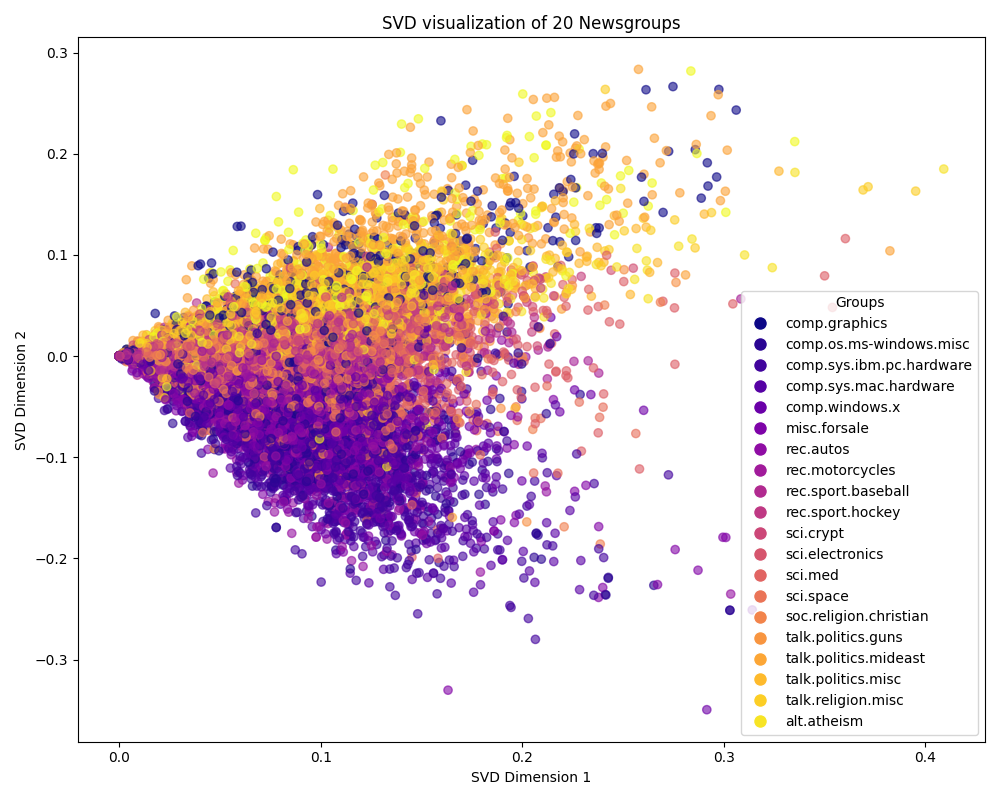

In [7]:
plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_svd[:, 0], X_svd[:, 1], alpha=0.6, c=newsgroups.target, cmap='plasma', label=newsgroups.target)

categories = np.unique(newsgroups.target)
category_labels = newsgroups.target_names
category_labels.append(category_labels.pop(0))

# Create a legend with category labels
handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=plt.cm.plasma(i / len(categories)), markersize=10) for i in categories]
plt.legend(handles, category_labels, title="Groups")

# Add titles and labels
plt.title('SVD visualization of 20 Newsgroups')
plt.xlabel('SVD Dimension 1')
plt.ylabel('SVD Dimension 2')
plt.tight_layout()
plt.show()

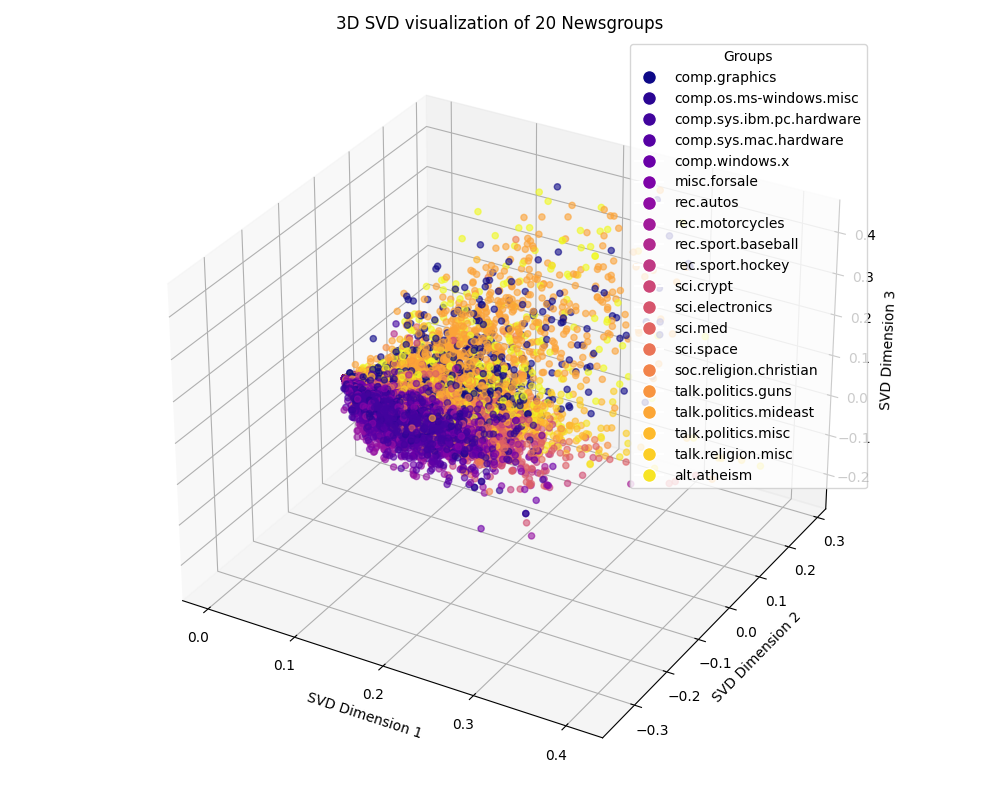

In [8]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Create 3D scatter plot
scatter_3d = ax.scatter(X_svd[:, 0], X_svd[:, 1], X_svd[:, 2], alpha=0.6, c=newsgroups.target, cmap='plasma')

# Set titles and labels for the 3D plot
ax.set_title('3D SVD visualization of 20 Newsgroups')
ax.set_xlabel('SVD Dimension 1')
ax.set_ylabel('SVD Dimension 2')
ax.set_zlabel('SVD Dimension 3')

# Create a legend with category labels
handles_3d = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=plt.cm.plasma(i / len(categories)), markersize=10) for i in categories]
plt.legend(handles_3d, category_labels, title="Groups", loc='upper right')

plt.tight_layout()
plt.show()

In [12]:
terms = vectorizer.get_feature_names_out()
top_terms = 5
for i, topic in enumerate(np.diag(svd.singular_values_) @ svd.components_):
    print(f"Top words for topic {i+1}:")
    top_words = [terms[i] for i in topic.argsort()[-top_terms:]]  # Get top 10 words for each topic
    print(" ".join(top_words))
    print()

Top words for topic 1:
know people like just don

Top words for topic 2:
think believe jesus people god

Top words for topic 3:
does bible windows jesus god

Top words for topic 4:
ide game god scsi drive

Top words for topic 5:
government chip key scsi drive

Top words for topic 6:
problem file drive dos windows

Top words for topic 7:
just does don know thanks

Top words for topic 8:
does chip know game key

